# Simple Physics-Informed Neural Network (PINN)

这个 Notebook 实现了一个最简单的PINN，用于求解一个一维常微分方程（ODE）。

**问题定义：**
- ODE: $\frac{du}{dt} = \cos(2\pi t)$
- 初始条件 (IC): $u(0) = 1$
- 解析解: $u(t) = 1 + \frac{\sin(2\pi t)}{2\pi}$

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
torch.manual_seed(42)

## 1. 定义神经网络模型
我们使用一个简单的全连接前馈神经网络作为基于物理的神经网络。
这个网络的输入是时间 $t$，输出是预测的函数值 $u(t)$。

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # 包含3个隐藏层，每层32个神经元，使用Tanh激活函数
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
        
    def forward(self, t):
        return self.net(t)

## 2. 定义解析解 (用于评估)

In [3]:
def exact_solution(t):
    return 1.0 + torch.sin(2 * np.pi * t) / (2 * np.pi)

## 3. 准备训练数据 (配置点和初始点)
不需要真实的 $u(t)$ 数据，只需要定义方程求解域内的一系列“采样点”（Collocation points）来计算PDE的残差。

In [4]:
# 在 [0, 2] 的区间内均匀采样100个点，并将 requires_grad 设置为 True，
# 这是因为我们需要计算网络输出相对于输入 t 的梯度 (du/dt)
t_physics = torch.linspace(0, 2, 100).view(-1, 1).requires_grad_(True)

# 初始条件点 t = 0
t_ic = torch.tensor([[0.0]])

## 4. 模型初始化与训练循环

In [5]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 5000

print("开始训练...")
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # --- 1. 计算初始条件损失 (IC Loss) ---
    u_ic = model(t_ic)
    loss_ic = torch.mean((u_ic - 1.0)**2)  # u(0) 应该等于 1.0
    
    # --- 2. 计算物理方程损失 (PDE Loss) ---
    # 前向传播得到在区间内的模型预测值 u(t)
    u = model(t_physics)
    
    # 计算一阶导数 du/dt
    # torch.autograd.grad 用于自动求导获取梯度
    du_dt = torch.autograd.grad(
        outputs=u, 
        inputs=t_physics, 
        grad_outputs=torch.ones_like(u), 
        create_graph=True
    )[0]
    
    # PDE损失：MSE( du/dt - cos(2*pi*t) )
    loss_pde = torch.mean((du_dt - torch.cos(2 * np.pi * t_physics))**2)
    
    # --- 3. 总损失与反向传播 ---
    loss = loss_pde + loss_ic
    loss.backward()
    optimizer.step()
    
    loss_history.append(loss.item())
    
    if epoch % 500 == 0:
        print(f"Epoch: {epoch:04d} | Total Loss: {loss.item():.5f} | PDE Loss: {loss_pde.item():.5f} | IC Loss: {loss_ic.item():.5f}")

print("训练完成！")

开始训练...
Epoch: 0000 | Total Loss: 1.52651 | PDE Loss: 0.51056 | IC Loss: 1.01595
Epoch: 0500 | Total Loss: 0.18024 | PDE Loss: 0.18022 | IC Loss: 0.00002
Epoch: 1000 | Total Loss: 0.00035 | PDE Loss: 0.00035 | IC Loss: 0.00000
Epoch: 1500 | Total Loss: 0.00022 | PDE Loss: 0.00021 | IC Loss: 0.00001
Epoch: 2000 | Total Loss: 0.00007 | PDE Loss: 0.00007 | IC Loss: 0.00000
Epoch: 2500 | Total Loss: 0.00003 | PDE Loss: 0.00003 | IC Loss: 0.00000
Epoch: 3000 | Total Loss: 0.00002 | PDE Loss: 0.00002 | IC Loss: 0.00000
Epoch: 3500 | Total Loss: 0.00002 | PDE Loss: 0.00002 | IC Loss: 0.00000
Epoch: 4000 | Total Loss: 0.00002 | PDE Loss: 0.00002 | IC Loss: 0.00000
Epoch: 4500 | Total Loss: 0.00001 | PDE Loss: 0.00001 | IC Loss: 0.00000
训练完成！


## 5. 结果可视化评估

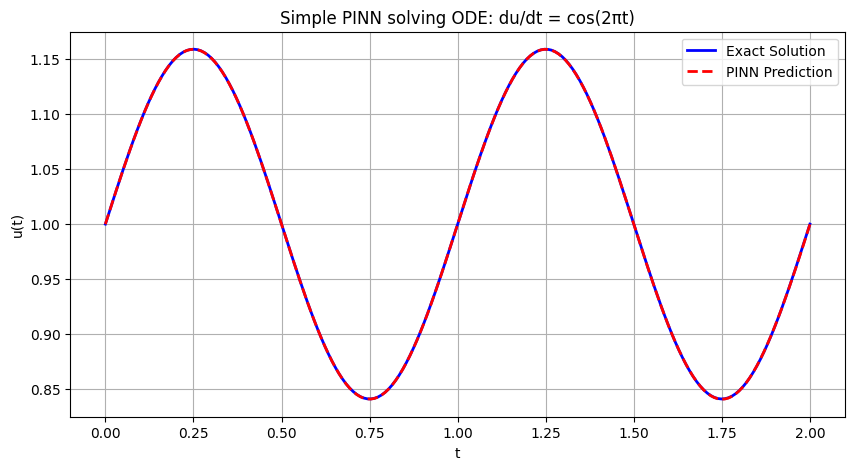

In [6]:
model.eval()
t_test = torch.linspace(0, 2, 200).view(-1, 1)

with torch.no_grad():
    u_pred = model(t_test)
    
u_exact = exact_solution(t_test)

plt.figure(figsize=(10, 5))
plt.plot(t_test.numpy(), u_exact.numpy(), label="Exact Solution", color="blue", linewidth=2)
plt.plot(t_test.numpy(), u_pred.numpy(), '--', label="PINN Prediction", color="red", linewidth=2)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Simple PINN solving ODE: du/dt = cos(2\u03c0t)")
plt.legend()
plt.grid(True)
plt.show()